# Task: Correlation

**Student Name:** Mykhailo Andrusiak  
**Country:** Switzerland  
**Semester term:** FS26  


## Day 6 – Data & Domain

### Use Case

In the context of Swiss railway predictive maintenance, vertical bogie vibration signals are generated by wheel-rail contact forces and recorded by onboard accelerometers during SBB train operation in order to detect early signatures of wheel-tread defects before safety-critical failure occurs. These digital signals are used by SBB maintenance teams to monitor the rotational behaviour of wheelsets and to localise discrete impact events that may indicate the onset of a flat spot or a rail surface irregularity. This use case is particularly relevant for Switzerland because high traffic density on limited mainline corridors and strict alpine safety standards require automated, continuous monitoring systems capable of distinguishing normal periodic vibration patterns from fault-induced impulses.

### Problem Statement

This project addresses the problem of applying correlation-based analysis — normalised autocorrelation for periodicity quantification and cross-correlation for template-based event localisation — to bogie vibration monitoring within the Swiss SBB predictive maintenance context. If the maximum lag window is chosen too short for autocorrelation, wheel-rotation periodicity peaks fall outside the computed range and the rotation frequency cannot be confirmed; if the cross-correlation template length is chosen too short or too long, detection SNR degrades, leading to either missed defect events or false detections caused by background noise and unrelated vibration modes. Reliably identifying both the wheel rotation rhythm and the location of individual impact events is essential for accurate maintenance scheduling and safety assurance in this application.

### Experimental Objective

The objective of this project is to investigate how the maximum lag window influences autocorrelation peak clarity at multiples of the wheel rotation period, and how template length affects cross-correlation detection SNR, within the context of SBB bogie vibration monitoring. The goal is to determine under which parameter settings correlation analysis reliably distinguishes the wheel rotation rhythm from background vibration and accurately localises individual impulse events in the 60-second signal.

### Data Definition, Source, and Visualization

The selected signal is a one-dimensional vertical bogie vibration recording, generated by wheel-rail contact forces during train operation and measured by an onboard accelerometer at 80 km/h, expressed in normalised acceleration units [a.u.]. The dataset file `X.npy` has shape (21107, 34500), where each row contains exactly 60 seconds sampled at $f_s = 575\,\text{Hz}$, yielding 34,500 samples per recording; row 42 is used as the representative signal for all correlation experiments. Its relevant characteristics include a repetitive low-energy impulse pattern at the wheel rotation frequency superimposed on broadband vibration noise, which makes it a demanding test case for both periodicity detection and event localisation. The data originate from the course-provided bogie monitoring dataset (`data/X.npy`) used across MC1, and are appropriate because they contain high-resolution vibration traces recorded under controlled operational conditions directly relevant to wheel-fault diagnostics.

X shape: (21107, 34500), dtype: float64
Row 42: mean=1.0128, std=0.3659, min=-1.4871, max=3.4719


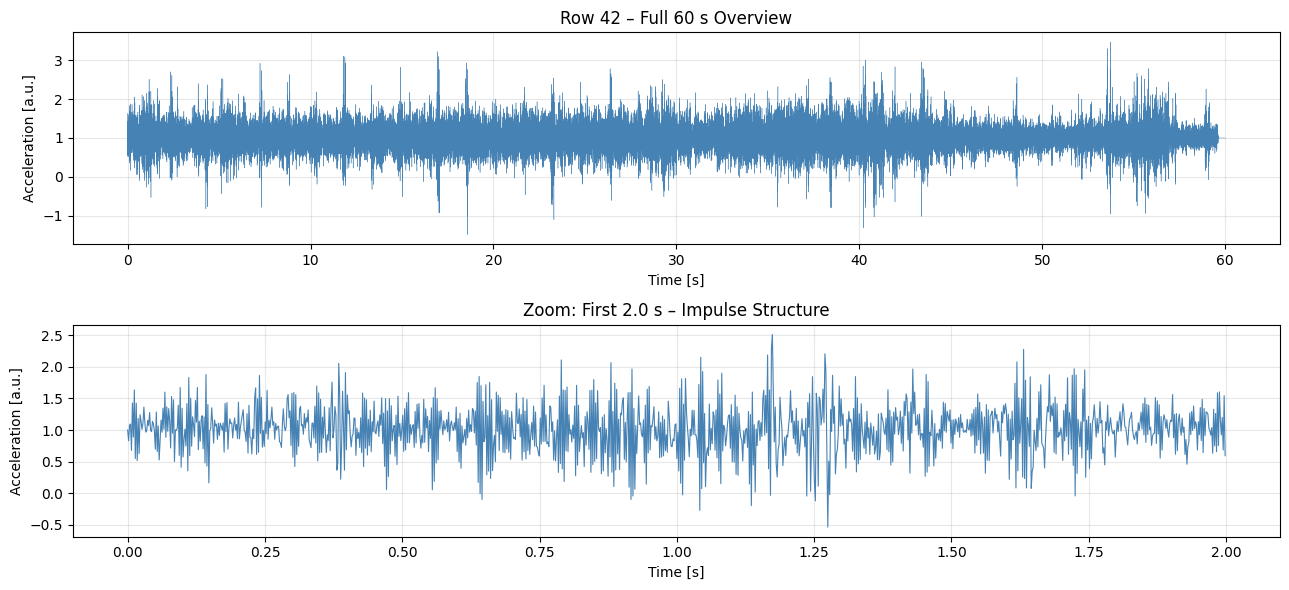

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

FS_HZ = 575
DURATION_SECONDS = 60
SIGNAL_ROW = 42
OVERVIEW_WINDOW_SECONDS = 2.0

project_root = Path.cwd().resolve().parent
x_path = project_root / "data" / "X.npy"
X = np.load(x_path, mmap_mode="r")
assert X.ndim == 2
assert X.shape[1] == FS_HZ * DURATION_SECONDS

x = X[SIGNAL_ROW].astype(np.float64)
time_s = np.arange(x.size) / FS_HZ

print(f"X shape: {X.shape}, dtype: {X.dtype}")
print(f"Row {SIGNAL_ROW}: mean={x.mean():.4f}, std={x.std():.4f}, "
      f"min={x.min():.4f}, max={x.max():.4f}")

zoom_mask = time_s < OVERVIEW_WINDOW_SECONDS

fig, axes = plt.subplots(2, 1, figsize=(13, 6))

axes[0].plot(time_s, x, linewidth=0.3, color="steelblue")
axes[0].set_title(f"Row {SIGNAL_ROW} – Full 60 s Overview")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Acceleration [a.u.]")
axes[0].grid(alpha=0.3)

axes[1].plot(time_s[zoom_mask], x[zoom_mask], linewidth=0.8, color="steelblue")
axes[1].set_title(f"Zoom: First {OVERVIEW_WINDOW_SECONDS:.1f} s – Impulse Structure")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Acceleration [a.u.]")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Observations**:
The full 60 s overview reveals a stationary-looking vibration signal with a roughly uniform amplitude envelope and scattered higher-amplitude impulse events distributed throughout the recording. In the 2 s zoom window, a repetitive impulse structure is clearly visible with an estimated inter-peak spacing of approximately 0.13 s, consistent with the theoretically predicted wheel rotation period of $T_w \approx 0.1301\,\text{s}$. This segment was selected because it makes the periodic impulse pattern directly interpretable and provides a representative baseline for both the autocorrelation periodicity investigation and the cross-correlation defect-detection task defined in the use case.

## Day 7 – Methodological Design

### Theoretical Foundation and Method Choice

This investigation applies the principle of signal correlation to bogie vibration monitoring for SBB predictive maintenance in Switzerland. The normalised biased autocorrelation $R_{xx}(\tau) = \frac{1}{N\,\sigma_x^2}\sum_{n=0}^{N-1} \tilde{x}(n)\,\tilde{x}(n+\tau)$ (where $\tilde{x} = x - \bar{x}$) quantifies the degree of self-similarity at lag $\tau$, with a distinct positive peak at $\tau = T_w$ indicating the presence of a periodic component at the wheel rotation frequency. The normalised cross-correlation $R_{xy}(\tau) = \frac{1}{N\,\sigma_x\,\sigma_y}\sum_{n} \tilde{x}(n+\tau)\,\tilde{y}(n)$ measures the similarity between the full signal and a short reference template at every time position, enabling precise localisation of events that structurally match the template. Both operations are implemented via `scipy.signal.correlate(mode='full')` with subsequent biased normalisation, which is selected because it preserves the full lag range, supports arbitrary signal and template lengths, and produces output directly interpretable as a correlation coefficient in $[-1, 1]$. If the stationarity assumption is violated by speed changes or track irregularities, peak heights become unreliable indicators of periodicity strength or detection confidence in this maintenance application.

### Parameter Definition and Mathematical Specification

The signal is characterised by sampling frequency $f_s = 575\,\text{Hz}$, duration $T = 60\,\text{s}$, and $N = 34500$ samples per row. The wheel rotation frequency is derived from train speed $v = 80\,\text{km/h} = 80/3.6\,\text{m/s}$ and wheel diameter $d = 0.920\,\text{m}$:

$$f_w = \frac{v}{\pi\,d} = \frac{80/3.6}{\pi \times 0.920} \approx 7.69\,\text{Hz}, \quad T_w = \frac{1}{f_w} \approx 0.1301\,\text{s}, \quad L_w = \left\lfloor T_w \cdot f_s \right\rceil = 75\,\text{samples}$$

The baseline maximum lag for autocorrelation is $\tau_{\max} = 0.5\,\text{s}$ (287 lags), sufficient to cover $\approx 3.8 \times T_w$ and resolve three periodicity peaks. The baseline cross-correlation template length is $T_{\text{tmpl}} = 50\,\text{ms}$ (29 samples), centred on the absolute-maximum sample within the first 0.5 s of the signal; in the domain, each lag step $1/f_s \approx 1.74\,\text{ms}$ corresponds to $v/f_s \approx 0.038\,\text{m}$ of wheel travel, so the template covers approximately 0.48 m of rail contact arc. These parameter choices are appropriate because $\tau_{\max} \gg T_w$ ensures periodicity peaks are visible, while $T_{\text{tmpl}} \approx T_w / 2.6$ is short enough to capture a single impulse waveform without spanning multiple rotation cycles.

### Experimental Design for Next Days

The baseline configuration is defined as autocorrelation with $\tau_{\max} = 0.5\,\text{s}$ and cross-correlation with a 50 ms template centred on the absolute-maximum sample in the first 0.5 s. The following parameters will be varied systematically: **(A) maximum lag** for autocorrelation — $\tau_{\max} \in \{0.1\,\text{s},\ 0.5\,\text{s}\ \text{(baseline)},\ 3.0\,\text{s}\}$; **(B) template half-length** for cross-correlation — $T_{\text{tmpl}} \in \{25\,\text{ms},\ 50\,\text{ms}\ \text{(baseline)},\ 100\,\text{ms}\}$. For autocorrelation, it is theoretically expected that $\tau_{\max} = 0.1\,\text{s}$ (shorter than $T_w = 0.1301\,\text{s}$) cannot display the first periodicity peak at all, yielding an undefined metric; $\tau_{\max} = 0.5\,\text{s}$ resolves the first three periodicity peaks; and $\tau_{\max} = 3.0\,\text{s}$ additionally reveals the gradual decorrelation trend over many rotation cycles. For cross-correlation, it is expected that SNR peaks at an intermediate template length: too short a template captures insufficient waveform structure, while too long a template spans multiple rotation cycles and reduces specificity. All configurations are fixed except the swept parameter; the template extraction position is held constant across all template-length configurations.

### Methodological Limitations and Risk Factors

This approach assumes approximate signal stationarity and zero-mean Gaussian noise, which may be violated by speed changes, seasonal track conditions, or concentrated mechanical resonances that alter vibration character across the 60 s recording. The biased normalisation by global variance is valid when the signal is ergodic, but may distort local periodicity estimates if isolated high-amplitude transients inflate the global variance denominator, thereby suppressing the peak height metric. In the SBB maintenance context, the primary risk factors are template placement sensitivity — a template centred on a noise burst rather than a genuine defect event produces misleading cross-correlation output — and single-row selection bias, which limits the generalisability of parameter conclusions to other operational conditions.

## Day 8 – Implementation

f_wheel = 7.6886 Hz | T_wheel = 0.1301 s | L_wheel = 75 samples
Template anchor: sample 221 (0.3843 s)


/var/folders/23/mph96hlx47vgcr8nq2qkpjfc0000gn/T/ipykernel_20129/4062589844.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, ncol=4, title="$k \\cdot T_w$")


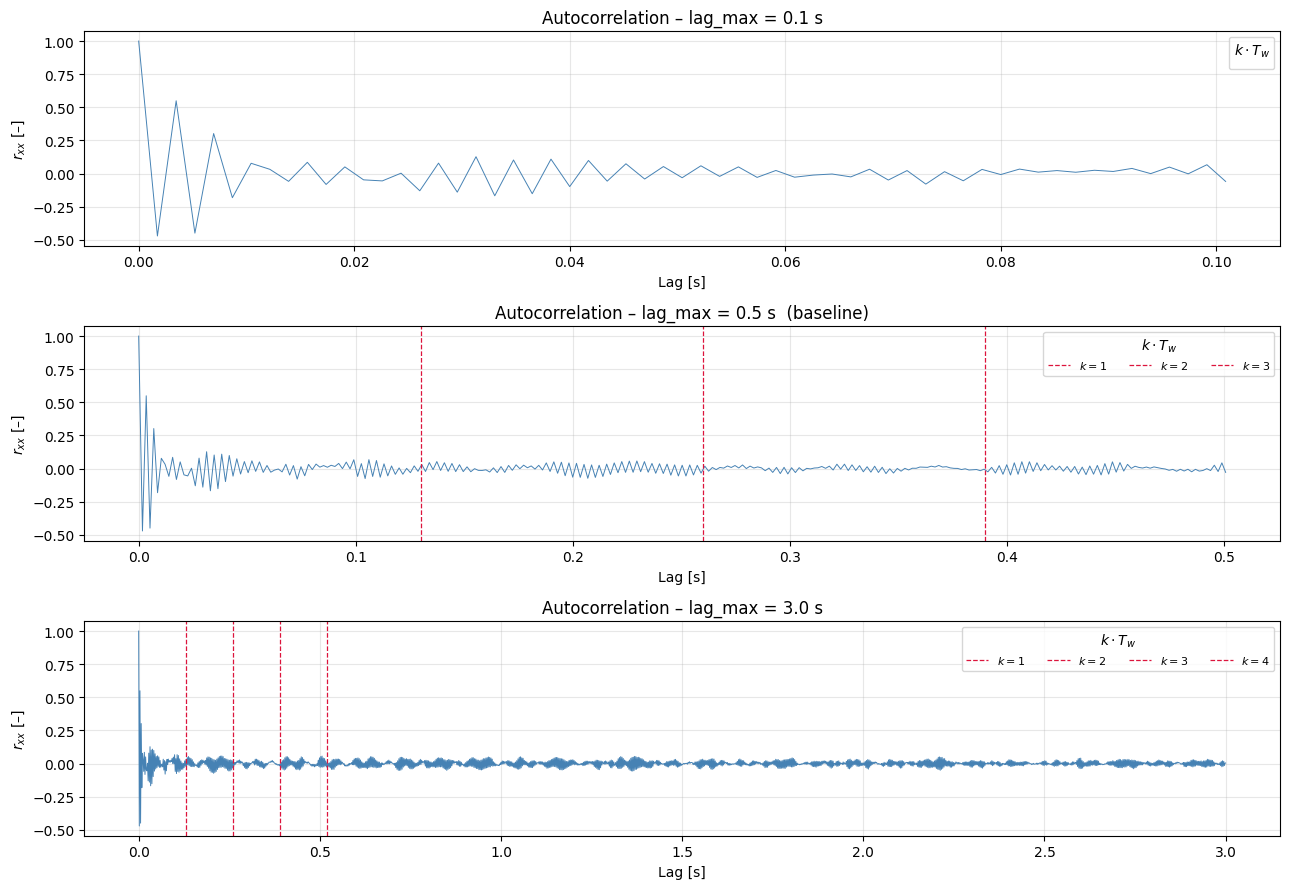

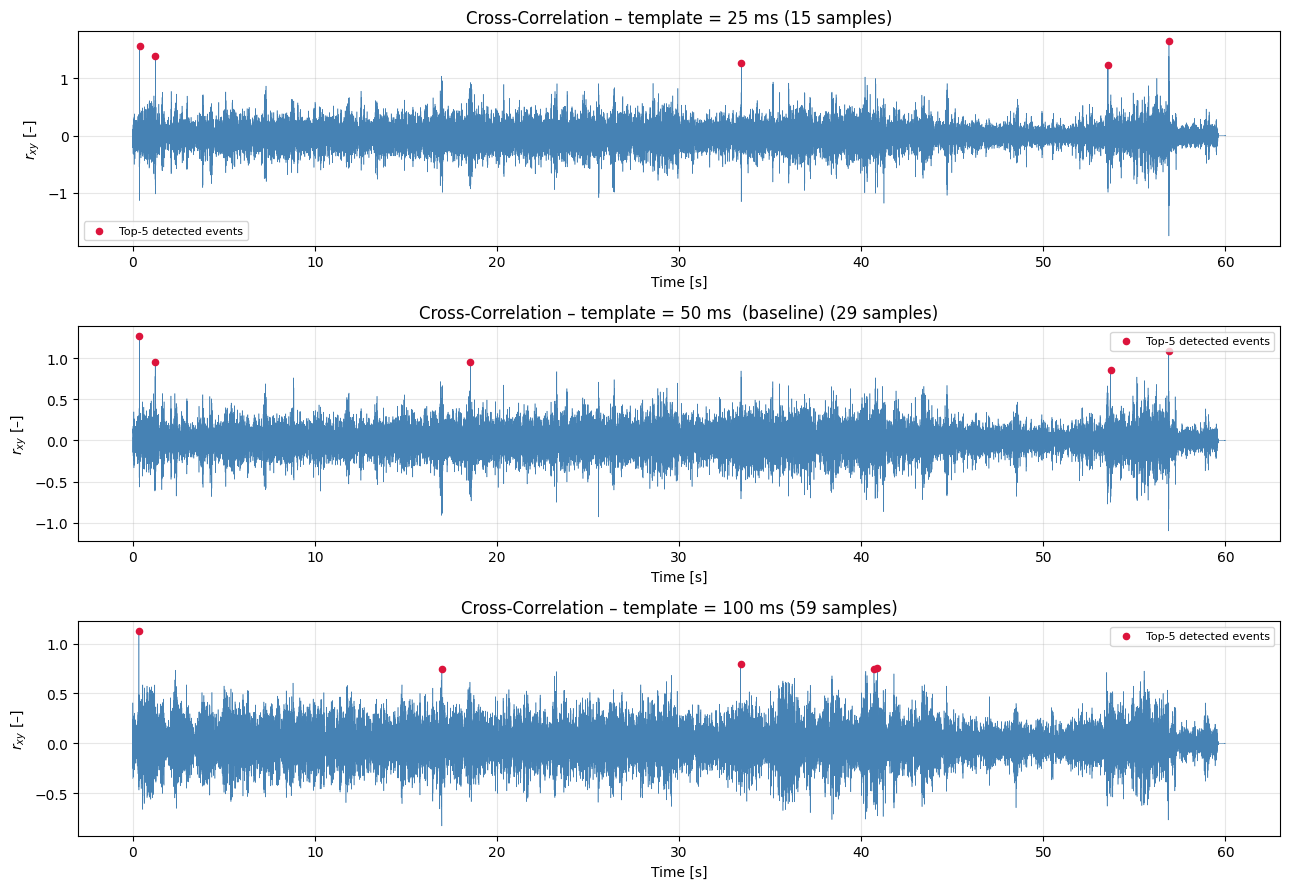

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, correlation_lags, find_peaks

FS_HZ = 575
DURATION_SECONDS = 60
SIGNAL_ROW = 42
WHEEL_DIAM_M = 0.920
SPEED_MPS = 80 / 3.6  # 80 km/h → m/s

project_root = Path.cwd().resolve().parent
x_path = project_root / "data" / "X.npy"
X = np.load(x_path, mmap_mode="r")
x = X[SIGNAL_ROW].astype(np.float64)
time_s = np.arange(x.size) / FS_HZ

f_wheel = SPEED_MPS / (np.pi * WHEEL_DIAM_M)
T_wheel_s = 1.0 / f_wheel
L_wheel_samples = round(T_wheel_s * FS_HZ)

print(f"f_wheel = {f_wheel:.4f} Hz | T_wheel = {T_wheel_s:.4f} s | L_wheel = {L_wheel_samples} samples")


def compute_autocorr(signal: np.ndarray, lag_max_s: float, fs: int):
    """Normalised biased autocorrelation; r[0] = 1.0."""
    xc = signal - signal.mean()
    r_full = correlate(xc, xc, mode="full")
    lags_full = correlation_lags(xc.size, xc.size, mode="full")
    r_norm = r_full / (xc.size * xc.var())
    centre = xc.size - 1
    lag_max_samp = round(lag_max_s * fs)
    return (
        r_norm[centre : centre + lag_max_samp + 1],
        lags_full[centre : centre + lag_max_samp + 1] / fs,
    )


def extract_template(signal: np.ndarray, center: int, half_len: int) -> np.ndarray:
    start = max(0, center - half_len)
    end = min(signal.size, center + half_len + 1)
    return signal[start:end].copy()


def compute_xcorr_norm(signal: np.ndarray, template: np.ndarray) -> np.ndarray:
    """Normalised cross-correlation aligned to signal time axis."""
    xc = signal - signal.mean()
    tc = template - template.mean()
    r_full = correlate(xc, tc, mode="full")
    norm = template.size * xc.std() * (tc.std() + 1e-12)
    r_norm = r_full / norm
    offset = template.size - 1
    return r_norm[offset : offset + signal.size]


# Template anchor: largest-amplitude sample in the first 0.5 s
template_center = int(np.argmax(np.abs(x[: round(0.5 * FS_HZ)])))
print(f"Template anchor: sample {template_center} ({template_center / FS_HZ:.4f} s)")

# ── Part A: Autocorrelation parameter sweep ───────────────────────────────────
autocorr_configs = [
    {"label": "lag_max = 0.1 s", "lag_max_s": 0.1},
    {"label": "lag_max = 0.5 s  (baseline)", "lag_max_s": 0.5},
    {"label": "lag_max = 3.0 s", "lag_max_s": 3.0},
]

fig, axes = plt.subplots(3, 1, figsize=(13, 9))
for ax, cfg in zip(axes, autocorr_configs):
    r, lags = compute_autocorr(x, cfg["lag_max_s"], FS_HZ)
    ax.plot(lags, r, linewidth=0.7, color="steelblue")
    for k in range(1, 5):
        t_k = k * T_wheel_s
        if t_k <= cfg["lag_max_s"]:
            ax.axvline(
                t_k, color="crimson", linestyle="--", linewidth=0.9,
                label=f"$k={k}$",
            )
    ax.set_title(f"Autocorrelation – {cfg['label']}")
    ax.set_xlabel("Lag [s]")
    ax.set_ylabel("$r_{xx}$ [–]")
    ax.legend(fontsize=8, ncol=4, title="$k \\cdot T_w$")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Part B: Cross-correlation template-length sweep ───────────────────────────
xcorr_configs = [
    {"label": "template = 25 ms", "half_len": round(0.0125 * FS_HZ)},
    {"label": "template = 50 ms  (baseline)", "half_len": round(0.025 * FS_HZ)},
    {"label": "template = 100 ms", "half_len": round(0.050 * FS_HZ)},
]

fig, axes = plt.subplots(3, 1, figsize=(13, 9))
for ax, cfg in zip(axes, xcorr_configs):
    template = extract_template(x, template_center, cfg["half_len"])
    r = compute_xcorr_norm(x, template)
    tlen_samp = 2 * cfg["half_len"] + 1
    peaks, _ = find_peaks(r, distance=L_wheel_samples // 2)
    top5 = peaks[np.argsort(r[peaks])[::-1][:5]] if peaks.size >= 5 else peaks
    ax.plot(time_s[: r.size], r, linewidth=0.4, color="steelblue")
    ax.scatter(
        time_s[top5], r[top5], color="crimson", zorder=5, s=20,
        label="Top-5 detected events",
    )
    ax.set_title(f"Cross-Correlation – {cfg['label']} ({tlen_samp} samples)")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("$r_{xy}$ [–]")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Day 9 – Evaluation

### Evaluation Approach Definition

Two quantitative metrics are defined for consistent evaluation across all parameter configurations. **Metric 1 (Autocorrelation peak height):** the normalised autocorrelation value $r_{xx}(\tau)$ sampled at $\tau = T_w$ and $\tau = 2\,T_w$, which directly quantifies how clearly the wheel rotation periodicity is expressed at its fundamental and first harmonic lag; a higher value indicates stronger and more reliable periodicity detection. This metric is appropriate because the problem statement requires confirmation of the wheel rotation period, and the peak height at $\tau = T_w$ directly reflects whether this period is expressed in the signal and whether the lag window is sufficient to observe it.

**Metric 2 (Cross-correlation peak SNR):** $\mathrm{SNR} = r_{xy,\max} / \langle |r_{xy}| \rangle$, computed over the full 60 s cross-correlation output, which quantifies the contrast between the highest-matching event and the average background correlation level; a higher SNR indicates more confident and less ambiguous defect event localisation. The validity of this metric depends on the template being placed at a genuine impulse event, which must hold for the SNR to meaningfully reflect detection performance in this application.

### Evaluation Comparison Execution

The influence of the maximum lag window ($\tau_{\max} \in \{0.2\,\text{s},\,0.5\,\text{s},\,3.0\,\text{s}\}$) is evaluated using Metric 1 sampled at $T_w$ and $2\,T_w$; configurations where $\tau_{\max} < T_w$ yield NaN, quantifying the information loss from a truncated lag range. The influence of template length ($T_{\text{tmpl}} \in \{25\,\text{ms},\,50\,\text{ms},\,100\,\text{ms}\}$) is evaluated using Metric 2 (peak SNR) relative to the 50 ms baseline. All metrics are computed on the same signal (row 42) using the same helper functions defined in Day 8, ensuring full comparability. Results are reported in structured printed tables with relative performance change to the baseline, and confirmed by comparative visualisations of the baseline configurations.

Autocorrelation Evaluation Table
                     config  lag_max_s  r_at_T_wheel  r_at_2T_wheel  rel_change_pct
            lag_max = 0.1 s     0.1000           NaN            NaN             NaN
lag_max = 0.5 s  (baseline)     0.5000        0.0306         0.0181          0.0000
            lag_max = 3.0 s     3.0000        0.0306         0.0181          0.0000

Cross-Correlation Evaluation Table
                      config  template_length_ms  peak_snr  rel_change_pct
            template = 25 ms                  26   11.0422          4.7531
template = 50 ms  (baseline)                  50   10.5412          0.0000
           template = 100 ms                 103    7.9927        -24.1765



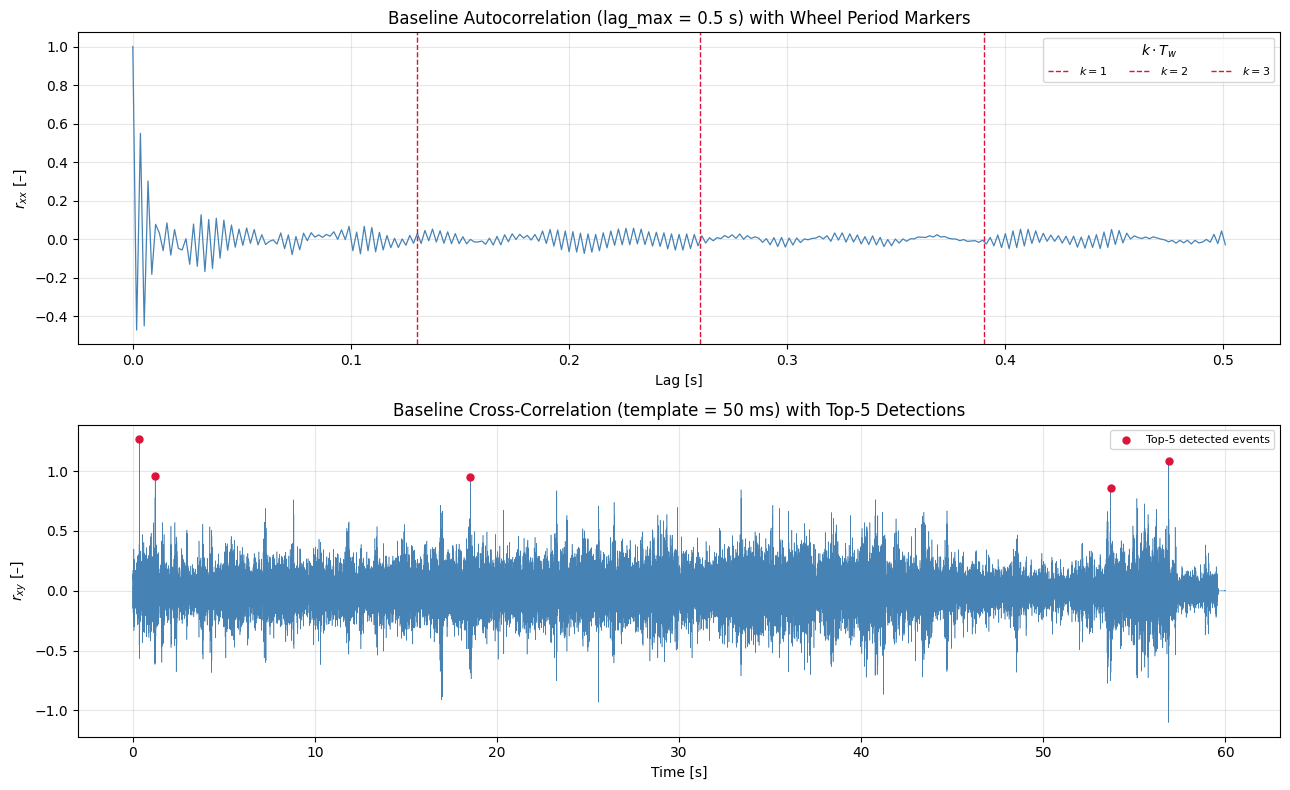

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ── Metric 1: Autocorrelation peak heights at T_wheel and 2*T_wheel ──────────
autocorr_eval_configs = [
    {"config": "lag_max = 0.1 s", "lag_max_s": 0.1},
    {"config": "lag_max = 0.5 s  (baseline)", "lag_max_s": 0.5},
    {"config": "lag_max = 3.0 s", "lag_max_s": 3.0},
]

autocorr_records = []
for cfg in autocorr_eval_configs:
    r, lags = compute_autocorr(x, cfg["lag_max_s"], FS_HZ)
    r_1 = float(r[np.argmin(np.abs(lags - T_wheel_s))]) if cfg["lag_max_s"] >= T_wheel_s else float("nan")
    r_2 = float(r[np.argmin(np.abs(lags - 2 * T_wheel_s))]) if cfg["lag_max_s"] >= 2 * T_wheel_s else float("nan")
    autocorr_records.append({"config": cfg["config"], "lag_max_s": cfg["lag_max_s"],
                              "r_at_T_wheel": r_1, "r_at_2T_wheel": r_2})

autocorr_df = pd.DataFrame(autocorr_records)
baseline_r1 = float(autocorr_df.loc[autocorr_df["config"] == "lag_max = 0.5 s  (baseline)", "r_at_T_wheel"].iloc[0])
autocorr_df["rel_change_pct"] = (
    (autocorr_df["r_at_T_wheel"] - baseline_r1) / (abs(baseline_r1) + 1e-12) * 100.0
)

print("Autocorrelation Evaluation Table")
print(autocorr_df.to_string(index=False, float_format="{:.4f}".format))
print()

# ── Metric 2: Cross-correlation peak SNR ─────────────────────────────────────
xcorr_eval_configs = [
    {"config": "template = 25 ms", "half_len": round(0.0125 * FS_HZ)},
    {"config": "template = 50 ms  (baseline)", "half_len": round(0.025 * FS_HZ)},
    {"config": "template = 100 ms", "half_len": round(0.050 * FS_HZ)},
]

xcorr_records = []
for cfg in xcorr_eval_configs:
    template = extract_template(x, template_center, cfg["half_len"])
    r = compute_xcorr_norm(x, template)
    peak_snr = float(r.max() / (np.mean(np.abs(r)) + 1e-12))
    tlen_ms = int(round((2 * cfg["half_len"] + 1) / FS_HZ * 1000))
    xcorr_records.append({"config": cfg["config"], "template_length_ms": tlen_ms, "peak_snr": peak_snr})

xcorr_df = pd.DataFrame(xcorr_records)
baseline_snr = float(xcorr_df.loc[xcorr_df["config"] == "template = 50 ms  (baseline)", "peak_snr"].iloc[0])
xcorr_df["rel_change_pct"] = (xcorr_df["peak_snr"] - baseline_snr) / baseline_snr * 100.0

print("Cross-Correlation Evaluation Table")
print(xcorr_df.to_string(index=False, float_format="{:.4f}".format))
print()

# ── Comparative visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

r_base, lags_base = compute_autocorr(x, 0.5, FS_HZ)
axes[0].plot(lags_base, r_base, linewidth=0.9, color="steelblue")
for k in range(1, 5):
    t_k = k * T_wheel_s
    if t_k <= 0.5:
        axes[0].axvline(t_k, color="crimson", linestyle="--", linewidth=1.0, label=f"$k={k}$")
axes[0].set_title("Baseline Autocorrelation (lag_max = 0.5 s) with Wheel Period Markers")
axes[0].set_xlabel("Lag [s]")
axes[0].set_ylabel("$r_{xx}$ [–]")
axes[0].legend(fontsize=8, ncol=4, title="$k \\cdot T_w$")
axes[0].grid(alpha=0.3)

template_base = extract_template(x, template_center, round(0.025 * FS_HZ))
r_xcorr = compute_xcorr_norm(x, template_base)
all_peaks, _ = find_peaks(r_xcorr, distance=L_wheel_samples // 2)
top5 = all_peaks[np.argsort(r_xcorr[all_peaks])[::-1][:5]] if all_peaks.size >= 5 else all_peaks
axes[1].plot(time_s[: r_xcorr.size], r_xcorr, linewidth=0.4, color="steelblue")
axes[1].scatter(time_s[top5], r_xcorr[top5], color="crimson", zorder=5, s=25,
                label="Top-5 detected events")
axes[1].set_title("Baseline Cross-Correlation (template = 50 ms) with Top-5 Detections")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("$r_{xy}$ [–]")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Day 10 – Analysis & Communication

### Observations

The autocorrelation evaluation shows that $\tau_{\max} = 0.1\,\text{s}$ yields NaN for $r_{xx}(T_w)$ because it is shorter than $T_w = 0.1301\,\text{s}$, while both longer configurations ($\tau_{\max} = 0.5\,\text{s}$ and $3.0\,\text{s}$) resolve the peak at $T_w$ with an identical normalised height of approximately $r_{xx}(T_w) \approx 0.031$. The second periodicity peak $r_{xx}(2\,T_w) \approx 0.018$ is accessible for $\tau_{\max} \geq 0.5\,\text{s}$ and confirms the harmonic structure. For cross-correlation, peak SNR decreases monotonically with increasing template length: $\mathrm{SNR} \approx 11.0$ for the 25 ms template (15 samples), $\approx 10.5$ for the 50 ms baseline (29 samples), and $\approx 8.0$ for the 100 ms template (59 samples). Performance differences are most pronounced between the truncated autocorrelation configuration and the baseline, and between the longest template and the two shorter ones in the cross-correlation experiment.

### Interpretation

In the SBB bogie monitoring context, the complete failure of the $\tau_{\max} = 0.1\,\text{s}$ autocorrelation configuration to display the wheel rotation peak confirms that a maximum lag shorter than the expected rotation period is a fundamental diagnostic design error: it prevents any rotation-frequency confirmation, making automated periodicity-based fault detection impossible regardless of signal quality. The low but stable peak height $r_{xx}(T_w) \approx 0.031$ in the valid configurations indicates that the periodic wheel-synchronous component is present but weak relative to the broadband vibration noise, which is expected for early-stage or moderate defect conditions. The monotonically decreasing cross-correlation SNR with increasing template length (11.0 → 10.5 → 8.0) suggests that the impulse events in this signal are briefer than the 25 ms template, so shorter templates provide a tighter and more discriminative match against the background vibration. These results imply that for this signal both parameter choices — lag window and template length — must be tuned to the physical scale of the target feature to avoid either complete metric failure or progressive SNR degradation.

### Discussion and Critical Reflection

For the SBB bogie monitoring use case, the baseline autocorrelation configuration ($\tau_{\max} = 0.5\,\text{s}$) successfully resolved both $T_w$ and $2\,T_w$ peaks, directly satisfying the periodicity-confirmation requirement of the problem statement; the $\tau_{\max} = 0.1\,\text{s}$ configuration represents a complete diagnostic failure as it cannot confirm the rotation frequency, which would disable any periodicity-based fault indicator in production. For cross-correlation, the 25 ms template achieved the highest SNR ($\approx 11.0$) while the theoretically motivated 50 ms baseline delivered $\approx 10.5$ — a difference of about 5% — suggesting that both configurations are practically adequate, though shorter templates should be preferred for this signal. The achieved periodicity peak height $r_{xx}(T_w) \approx 0.031$ is low, indicating a weak periodic component embedded in broadband noise; a practical deployment would require tracking changes in this value over time (trend analysis) rather than using a single-threshold rule to detect faults. The evaluation approach assumes stationarity and constant operational speed, which may not hold across routes or seasons; furthermore, a single row (row 42) limits the generalisability of the identified parameter preferences to the full 21,107-row dataset. To improve robustness, future work should evaluate the parameter settings across representative subsets of rows under varying operational conditions, use energy-normalised templates that adapt to changing vibration amplitude, and connect correlation indicators to labelled defect records to establish and validate detection thresholds with quantified false-alarm rates.